In [389]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import ast
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import math

In [372]:
def safe_literal_eval(val):
    if pd.isna(val):
        return None
    try:
        return ast.literal_eval(val)
    except (ValueError, SyntaxError):
        return None

In [107]:
contrib_2024 = pd.read_csv("../data/contributions/committees/corp_candidate_2024.csv")
corp_pac = pd.read_csv("../data/cpac/corporate_pacs_2004_2024.csv")

C:\Users\zih028\AppData\Local\Temp\ipykernel_4720\3144952284.py:1: DtypeWarning: Columns (11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  contrib_2024 = pd.read_csv("../data/contributions/committees/corp_candidate_2024.csv")


In [108]:
cpac_id = corp_pac["CMTE_ID"].unique().tolist()
contrib_2024 = contrib_2024[contrib_2024["CMTE_ID"].isin(cpac_id)]
contrib_2024 = contrib_2024[contrib_2024["TRANSACTION_AMT"] > 0]
contrib_pe = contrib_2024[(contrib_2024["YEAR"] == 2024) & (contrib_2024["MONTH"] > 8)].reset_index(drop=True)
contrib_ppe = contrib_2024[(contrib_2024["YEAR"] == 2023) | (contrib_2024["MONTH"] < 9)].reset_index(drop=True)

In [65]:
contrib_pe = contrib_2024[(contrib_2024["YEAR"] == 2024) & (contrib_2024["MONTH"] > 8)].reset_index(drop=True)
contrib_ppe = contrib_2024[(contrib_2024["YEAR"] == 2023) | (contrib_2024["MONTH"] < 9)].reset_index(drop=True)

In [21]:
def count_unique(x):
    return len(set(x))

In [66]:
stats_pe = contrib_pe.groupby("CMTE_ID").agg({"TRANSACTION_AMT": "sum", "TRAN_ID": "count", "CAND_ID": count_unique}).reset_index()
stats_ppe = contrib_ppe.groupby("CMTE_ID").agg({"TRANSACTION_AMT": "sum", "TRAN_ID": "count", "CAND_ID": count_unique}).reset_index()
stats_pe.columns = ["CMTE_ID", "amount", "count", "n_cands"]
stats_ppe.columns = ["CMTE_ID", "amount", "count", "n_cands"]

In [67]:
stats_df = pd.merge(stats_ppe, stats_pe,
                    how = "outer", on = "CMTE_ID",
                    suffixes = ("_ppe", "_pe")).fillna(0)

In [109]:
clean_contrib = contrib_2024.copy()
clean_contrib["MONTH"] = (clean_contrib["YEAR"] - 2023) * 12 + clean_contrib["MONTH"]
clean_contrib = clean_contrib[["CMTE_ID", "TRANSACTION_AMT", "CAND_ID", "SUB_ID", "MONTH"]]
clean_contrib = clean_contrib.groupby(["CMTE_ID", "MONTH"], as_index=False).agg({"TRANSACTION_AMT": "sum", "SUB_ID": "count", "CAND_ID":count_unique})
clean_contrib.columns = ["CMTE_ID", "MONTH", "amount", "count", "unique"]

df_index = pd.MultiIndex.from_product([clean_contrib["CMTE_ID"].unique(), range(1,25)], names = ["CMTE_ID", "MONTH"])

clean_contrib = clean_contrib.set_index(["CMTE_ID", "MONTH"]).reindex(df_index).fillna(0).reset_index()

In [273]:
value_cols = ["amount", "count", "unique"]

def zscore_rolling_spike(df, value_cols, window=6, alpha=0.5, scale_method='ema_absdev', scale_eps=1e-4):
    df = df.sort_values(["CMTE_ID", "MONTH"])
    result = []
    for id_val, group in tqdm(df.groupby("CMTE_ID")):
        group = group.sort_values("MONTH").reset_index(drop=True)
        N = len(group)
        if N < window:
            continue

        for i in range(window, N):
            row = {"CMTE_ID": id_val, "MONTH": group.loc[i, "MONTH"]}
            for col in value_cols:
                series = group[col].iloc[i-window:i+1]  # include current
                current = series.iloc[-1]
                past = series.iloc[:-1]

                # 1. Smoothed average (EMA)
                ema = past.ewm(alpha=alpha).mean().iloc[-1]

                # 2. Scale estimator
                if scale_method == "ema_absdev":
                    abs_dev = (past - ema).abs()
                    scale = abs_dev.ewm(alpha=alpha).mean().iloc[-1]
                elif scale_method == "std":
                    scale = past.std()
                elif scale_method == "iqr":
                    scale = np.percentile(past, 75) - np.percentile(past, 25)
                else:
                    raise ValueError(f"Unknown scale_method: {scale_method}")

                scale = max(scale, scale_eps)  # avoid divide-by-zero
                score = (current - ema) / scale

                row[f"{col}_spike_score"] = score
                row[f"{col}_is_spike"] = score > 2.5  # you can adjust this

            result.append(row)

    return pd.DataFrame(result)

In [312]:
spike_df_1 = zscore_rolling_spike(clean_contrib, value_cols, alpha = 0.2)
spike_df_2 = zscore_rolling_spike(clean_contrib, value_cols, alpha = 0.3)
spike_df_3 = zscore_rolling_spike(clean_contrib, value_cols, alpha = 0.4)

100%|██████████| 892/892 [00:16<00:00, 54.10it/s]


In [313]:
spike_df_1["spike"] = spike_df_1["amount_is_spike"] * spike_df_1["count_is_spike"] * spike_df_1["unique_is_spike"]
spike_df_2["spike"] = spike_df_2["amount_is_spike"] * spike_df_2["count_is_spike"] * spike_df_2["unique_is_spike"]
spike_df_3["spike"] = spike_df_3["amount_is_spike"] * spike_df_3["count_is_spike"] * spike_df_3["unique_is_spike"]

In [314]:
spike_cmte_1 = spike_df_1[(spike_df_1["spike"])]["CMTE_ID"].unique().tolist()
spike_cmte_3 = spike_df_3[(spike_df_3["spike"])]["CMTE_ID"].unique().tolist()
spike_cmte_2 = spike_df_2[(spike_df_2["spike"])]["CMTE_ID"].unique().tolist()

In [315]:
print(len(clean_contrib["CMTE_ID"].unique()))
print(len(spike_df_1[(spike_df_1["spike"]) & (spike_df_1["MONTH"] >= 20)]["CMTE_ID"].unique()))
print(len(spike_cmte_1))

print(len(spike_df_2[(spike_df_2["spike"]) & (spike_df_2["MONTH"] >= 20)]["CMTE_ID"].unique()))
print(len(spike_cmte_2))

print(len(spike_df_3[(spike_df_3["spike"]) & (spike_df_3["MONTH"] >= 20)]["CMTE_ID"].unique()))
print(len(spike_cmte_3))


892
358
796
372
810
403
837


In [321]:
merged_spike = pd.merge(spike_df_1[["CMTE_ID", "MONTH", "spike"]], spike_df_2[["CMTE_ID", "MONTH", "spike"]],
                        how = "left", on = ["CMTE_ID", "MONTH"],
                        suffixes = ("", "_2")).merge(
                            spike_df_3[["CMTE_ID", "MONTH", "spike"]],
                            how = "left", on = ["CMTE_ID", "MONTH"],
                            suffixes = ("", "_3")
                        )
merged_spike = merged_spike.rename(columns={"spike": "spike_1"})
merged_spike["spike"] = merged_spike["spike_1"] * merged_spike["spike_2"] * merged_spike["spike_3"]

In [336]:
spike_cmte = merged_spike[(merged_spike["spike"]) & (merged_spike["MONTH"] >= 20)]["CMTE_ID"].unique().tolist()

In [406]:
pe_hedging = pd.read_csv("../data/hedging/cpac_hedging_full_pe.csv")
ppe_hedging = pd.read_csv("../data/hedging/cpac_hedging_full_ppe.csv")
pe_hedging = pe_hedging[pe_hedging["YEAR"] == 2024]
ppe_hedging = ppe_hedging[ppe_hedging["YEAR"] == 2024]

pe_hedging = pe_hedging[['CMTE_ID', 'hedge_count', 'hedge_amount', 'house_hedge_count',
       'house_hedge_amount', 'senate_hedge_count', 'senate_hedge_amount',
       'balance_count', 'balance_amount', 'house_balance_count',
       'house_balance_amount', 'senate_balance_count', 'senate_balance_amount',
       'contribute_sum', 'n_states', 'n_cands', 'TRBC_Econ_Sector']]
ppe_hedging = ppe_hedging[['CMTE_ID', 'hedge_count', 'hedge_amount', 'house_hedge_count',
       'house_hedge_amount', 'senate_hedge_count', 'senate_hedge_amount',
       'balance_count', 'balance_amount', 'house_balance_count',
       'house_balance_amount', 'senate_balance_count', 'senate_balance_amount',
       'contribute_sum', 'n_states', 'n_cands', 'TRBC_Econ_Sector']]

pe_hedging["Sector"] = pe_hedging["TRBC_Econ_Sector"].apply(safe_literal_eval)
pe_hedging["Sector"] = pe_hedging["Sector"].apply(lambda x: x[0] if isinstance(x, list) else None)
pe_hedging.drop(columns = "TRBC_Econ_Sector", inplace=True)
ppe_hedging["Sector"] = ppe_hedging["TRBC_Econ_Sector"].apply(safe_literal_eval)
ppe_hedging["Sector"] = ppe_hedging["Sector"].apply(lambda x: x[0] if isinstance(x, list) else None)
ppe_hedging.drop(columns = "TRBC_Econ_Sector", inplace=True)

In [407]:
pe_spike_hedging = pe_hedging[pe_hedging["CMTE_ID"].isin(spike_cmte)].reset_index(drop=True)
pe_nspike_hedging = pe_hedging[~pe_hedging["CMTE_ID"].isin(spike_cmte)].dropna(subset="n_cands").reset_index(drop=True)
ppe_spike_hedging = ppe_hedging[ppe_hedging["CMTE_ID"].isin(spike_cmte)].reset_index(drop=True)
ppe_nspike_hedging = ppe_hedging[~ppe_hedging["CMTE_ID"].isin(spike_cmte)].dropna(subset="n_cands").reset_index(drop=True)

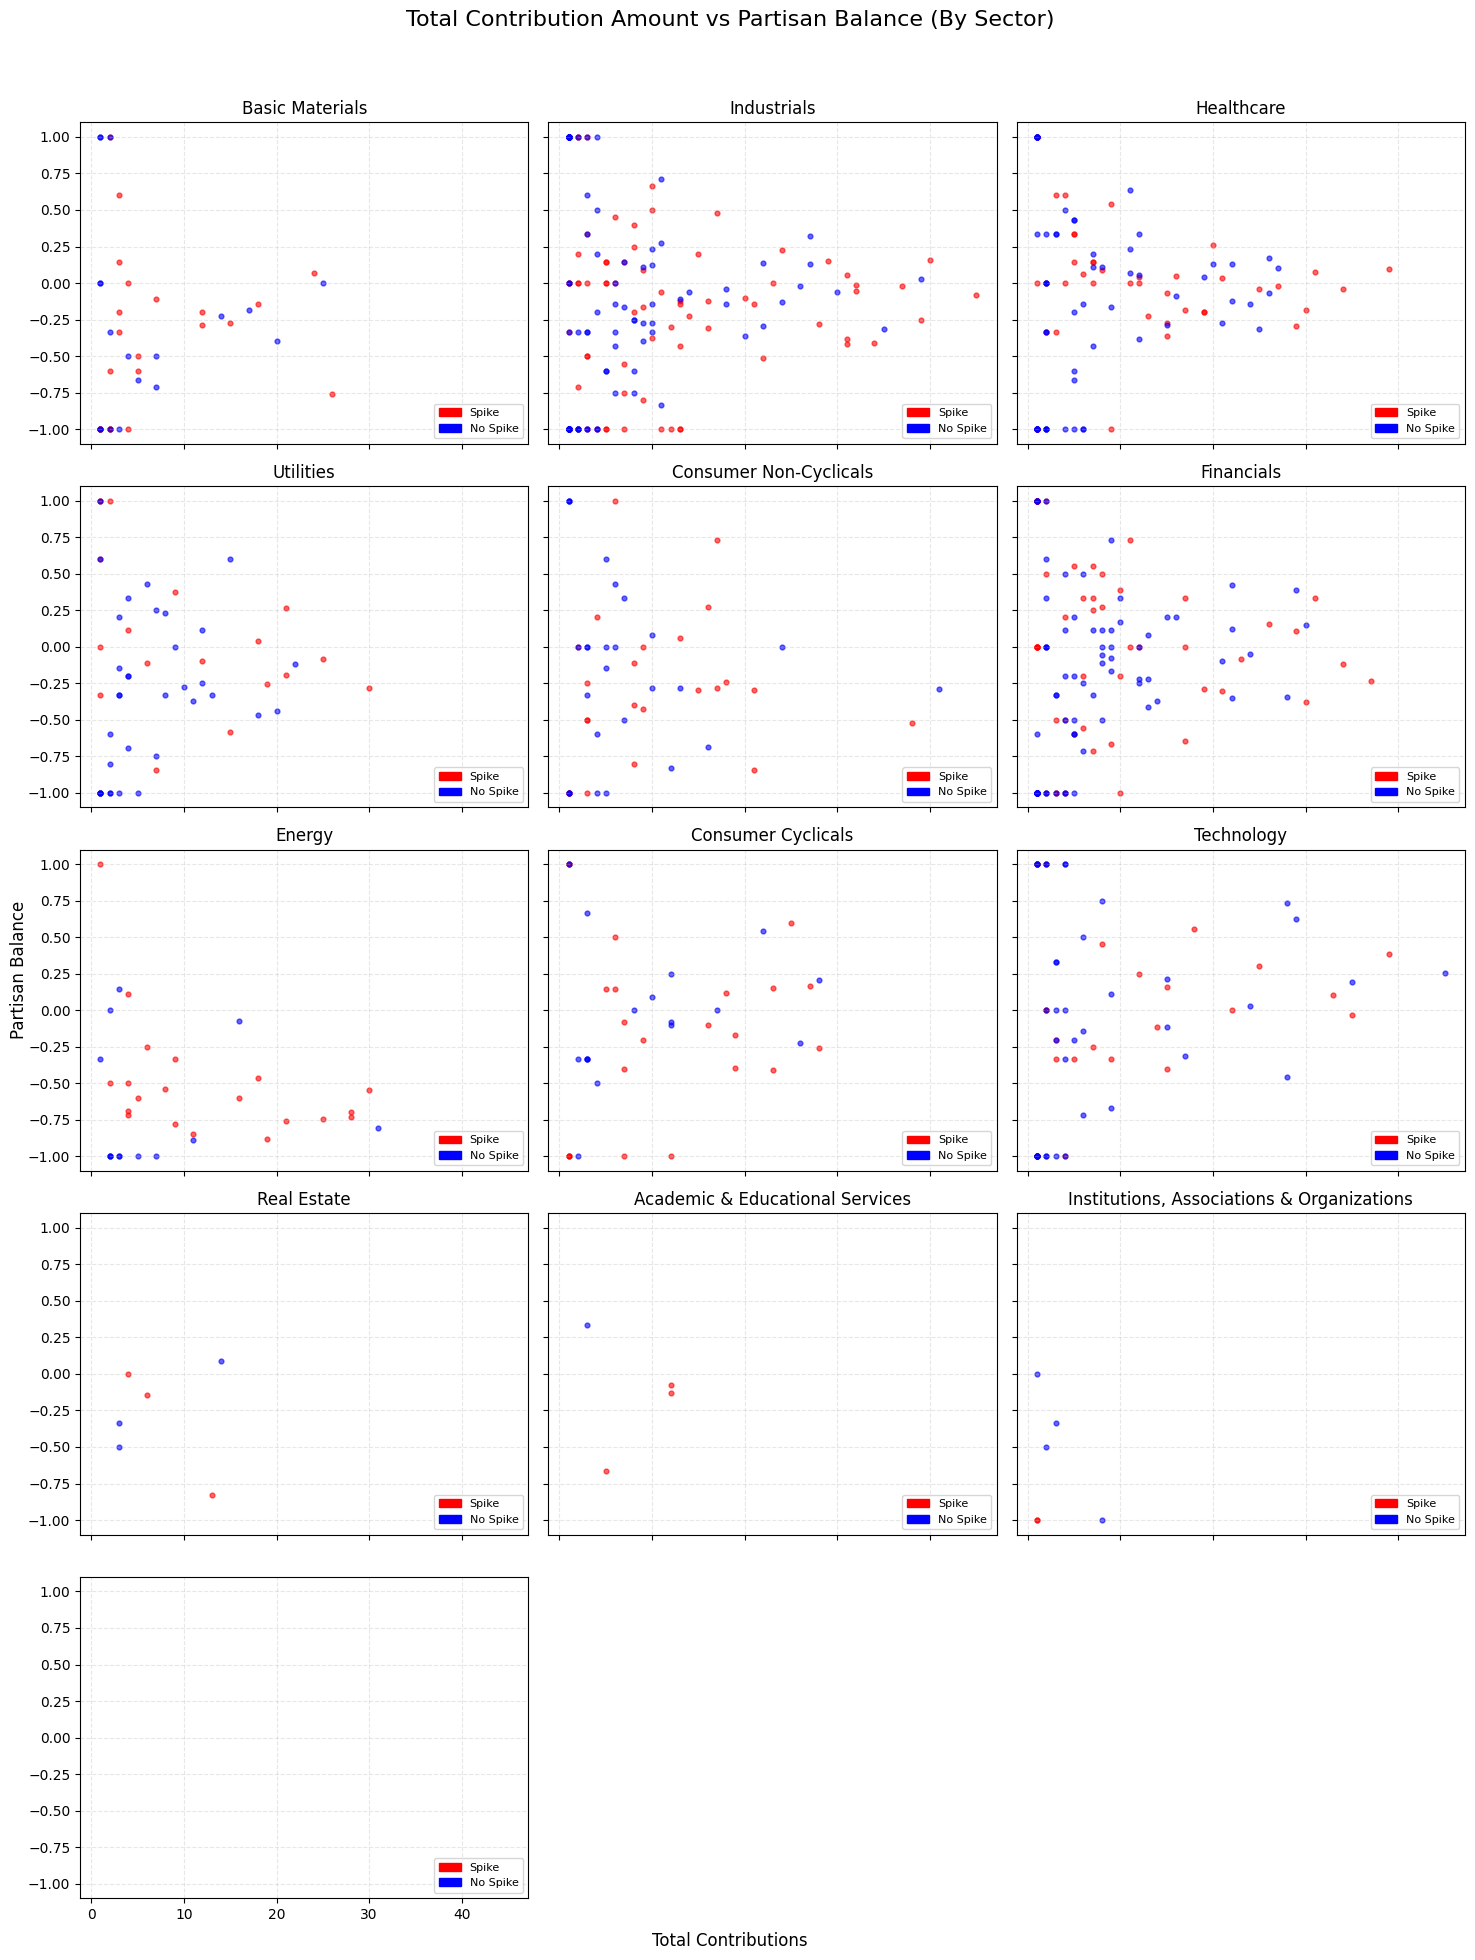

In [ ]:
# Get unique sectors
unique_sectors = pe_spike_hedging["Sector"].unique()
n_sectors = len(unique_sectors)

# Auto-determine subplot grid shape (e.g., 3 columns)
n_cols = 3
n_rows = math.ceil(n_sectors / n_cols)

# Set up the figure
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), sharex=True, sharey=True)
axes = axes.flatten()  # Flatten to 1D for easier iteration

# Assign colors
spike_colors = {"Spike": "red", "No Spike": "blue"}
legend_handles = [
    mpatches.Patch(color=spike_colors["Spike"], label="Spike"),
    mpatches.Patch(color=spike_colors["No Spike"], label="No Spike")
]

# Plot each sector in its own subplot
for i, sector in enumerate(unique_sectors):
    ax = axes[i]
    subset_spike = pe_spike_hedging[pe_spike_hedging["Sector"] == sector]
    subset_nspike = pe_nspike_hedging[pe_nspike_hedging["Sector"] == sector]
    ax.scatter(
        subset_spike["n_states"],
        subset_spike["balance_count"],
        color=spike_colors["Spike"],
        alpha=0.6,
        s=12
    )
    ax.scatter(
        subset_nspike["n_states"],
        subset_nspike["balance_count"],
        color=spike_colors["No Spike"],
        alpha=0.6,
        s=12
    )
    ax.set_title(sector)
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.legend(handles=legend_handles, loc="lower right", fontsize=8)

# Set global labels
fig.suptitle("Total Contribution Amount vs Partisan Balance (By Sector)", fontsize=16)
fig.supxlabel("Total Contributions", fontsize=12)
fig.supylabel("Partisan Balance", fontsize=12)

# Hide unused subplots if any
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [408]:
pe_spike_hedging

,CMTE_ID,hedge_count,hedge_amount,house_hedge_count,house_hedge_amount,senate_hedge_count,senate_hedge_amount,balance_count,balance_amount,house_balance_count,house_balance_amount,senate_balance_count,senate_balance_amount,contribute_sum,n_states,n_cands,Sector
0,C00002790,0.400000,0.500000,0.666667,0.800000,0.000000,0.000000,-0.600000,-0.500000,-0.333333,-0.200000,-1.000000,-1.000000,20000.0,5.0,5.0,Basic Materials
1,C00010470,0.589744,0.616780,0.594595,0.620690,0.500000,0.571429,-0.410256,-0.383220,-0.405405,-0.379310,-0.500000,-0.428571,228000.0,34.0,78.0,Industrials
2,C00016683,0.958333,0.818605,0.952381,0.909091,0.333333,0.214286,-0.041667,-0.181395,0.047619,-0.090909,-0.666667,-0.785714,107500.0,25.0,48.0,Healthcare
3,C00019653,0.807692,0.622754,0.765957,0.560510,0.800000,0.400000,-0.192308,-0.377246,-0.234043,-0.439490,0.200000,0.600000,169500.0,21.0,52.0,Utilities
4,C00024752,0.500000,0.589226,0.571429,0.674374,0.000000,0.000000,0.500000,0.410774,0.428571,0.325626,1.000000,1.000000,59400.0,10.0,16.0,Industrials
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
350,C00863027,0.000000,0.000000,NaN,NaN,0.000000,0.000000,-1.000000,-1.000000,NaN,NaN,-1.000000,-1.000000,3300.0,1.0,1.0,Industrials
351,C00863563,0.000000,0.000000,0.000000,0.000000,NaN,NaN,-1.000000,-1.000000,-1.000000,-1.000000,NaN,NaN,1000.0,1.0,1.0,Industrials
352,C00880351,0.000000,0.000000,NaN,NaN,0.000000,0.000000,-1.000000,-1.000000,NaN,NaN,-1.000000,-1.000000,2500.0,1.0,1.0,Industrials
353,C00882001,0.800000,0.785714,0.727273,0.743662,1.000000,0.885906,-0.200000,-0.214286,-0.272727,-0.256338,0.000000,-0.114094,50400.0,8.0,15.0,Industrials


In [420]:
spike_comparison = pd.merge(
    pe_spike_hedging[["CMTE_ID", "Sector", "balance_amount", "balance_count", "house_balance_amount", "house_balance_count", "contribute_sum", "n_states", "n_cands"]],
    ppe_spike_hedging[["CMTE_ID", "Sector", "balance_amount", "balance_count", "house_balance_amount", "house_balance_count", "contribute_sum", "n_states", "n_cands"]],
    how = "outer", on = ["CMTE_ID", "Sector"],
    suffixes = ("_pe", "_ppe")
)

nspike_comparison = pd.merge(
    pe_nspike_hedging[["CMTE_ID", "Sector", "balance_amount", "balance_count", "house_balance_amount", "house_balance_count", "contribute_sum", "n_states", "n_cands"]],
    ppe_nspike_hedging[["CMTE_ID", "Sector", "balance_amount", "balance_count", "house_balance_amount", "house_balance_count", "contribute_sum", "n_states", "n_cands"]],
    how = "outer", on = ["CMTE_ID", "Sector"],
    suffixes = ("_pe", "_ppe")
)

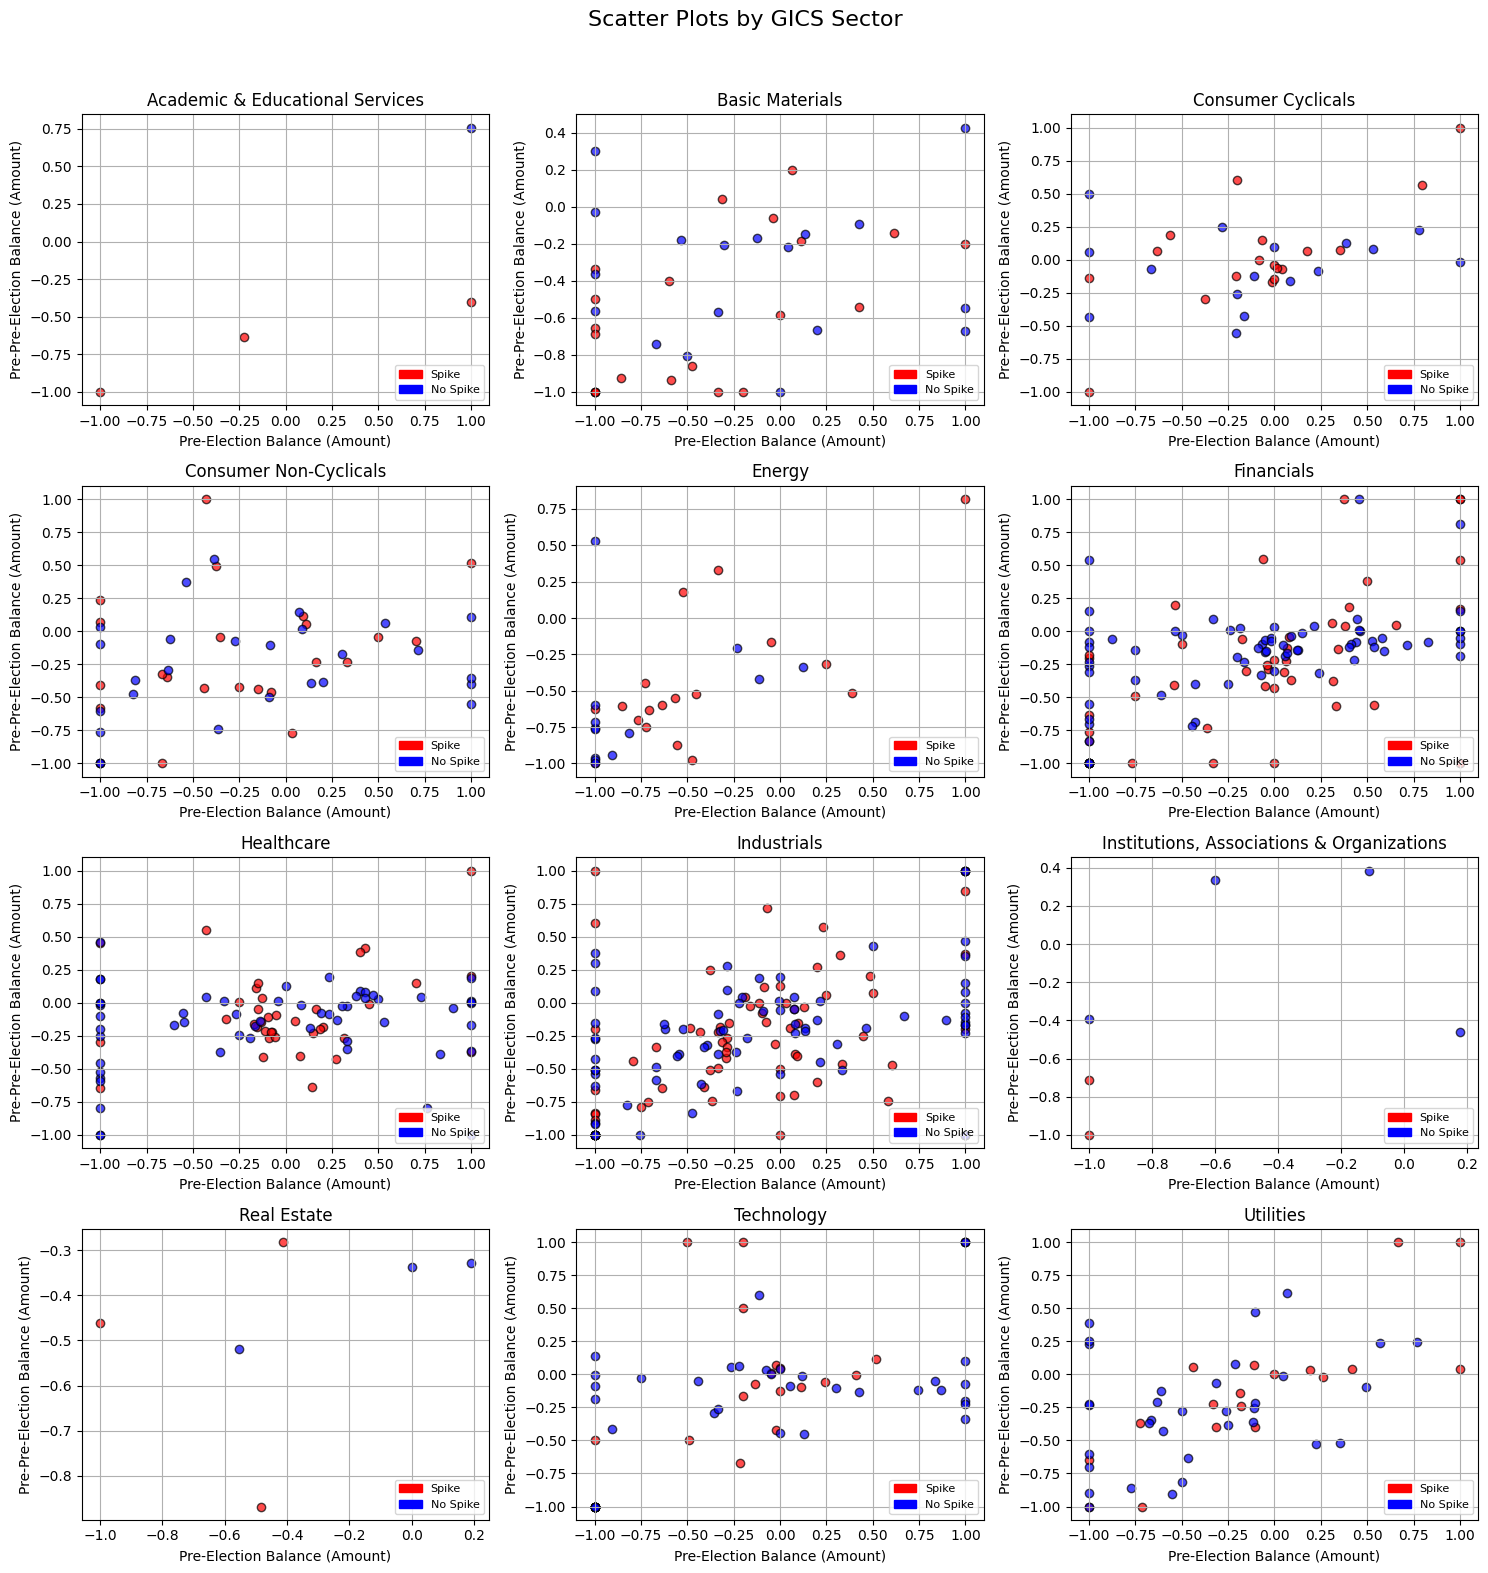

In [ ]:
sectors = spike_comparison['Sector'].dropna().unique()
sectors.sort()

# Plot layout
plots_per_row = 3
n_plots = len(sectors)
n_rows = math.ceil(n_plots / plots_per_row)

fig, axs = plt.subplots(n_rows, plots_per_row, figsize=(plots_per_row * 5, n_rows * 4), squeeze=False)

spike_colors = {"Spike": "red", "No Spike": "blue"}
legend_handles = [
    mpatches.Patch(color=spike_colors["Spike"], label="Spike"),
    mpatches.Patch(color=spike_colors["No Spike"], label="No Spike")
]

for i, sector in enumerate(sectors):
    row = i // plots_per_row
    col = i % plots_per_row
    ax = axs[row][col]
    
    spike_subset = spike_comparison[spike_comparison['Sector'] == sector]
    nspike_subset = nspike_comparison[nspike_comparison['Sector'] == sector]
    ax.scatter(
        spike_subset['house_balance_amount_pe'],
        spike_subset['house_balance_amount_ppe'],
        alpha=0.7,
        color = spike_colors["Spike"],
        edgecolor='k'
    )
    ax.scatter(
        nspike_subset['house_balance_amount_pe'],
        nspike_subset['house_balance_amount_ppe'],
        alpha=0.7,
        color = spike_colors["No Spike"],
        edgecolor='k'
    )
    ax.set_title(sector)
    ax.set_xlabel('Pre-Election Balance (Amount)')
    ax.set_ylabel('Pre-Pre-Election Balance (Amount)')
    ax.legend(handles=legend_handles, loc="lower right", fontsize=8)
    ax.grid(True)

# Hide any unused subplots
for j in range(n_plots, n_rows * plots_per_row):
    row, col = divmod(j, plots_per_row)
    axs[row][col].set_visible(False)

plt.suptitle('Scatter Plots by Sector', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])  # reserve space for title
plt.show()

In [425]:
spike_comparison["hedge_diff"] = abs(spike_comparison["house_balance_amount_pe"]) - abs(spike_comparison["house_balance_amount_ppe"])
spike_comparison["balance_diff"] = (spike_comparison["house_balance_amount_pe"]) - (spike_comparison["house_balance_amount_ppe"])
spike_comparison["total_contrib"] = spike_comparison["contribute_sum_pe"] + spike_comparison["contribute_sum_ppe"]
nspike_comparison["hedge_diff"] = abs(nspike_comparison["house_balance_amount_pe"]) - abs(nspike_comparison["house_balance_amount_ppe"])
nspike_comparison["balance_diff"] = (nspike_comparison["house_balance_amount_pe"]) - (nspike_comparison["house_balance_amount_ppe"])
nspike_comparison["total_contrib"] = nspike_comparison["contribute_sum_pe"] + nspike_comparison["contribute_sum_ppe"]


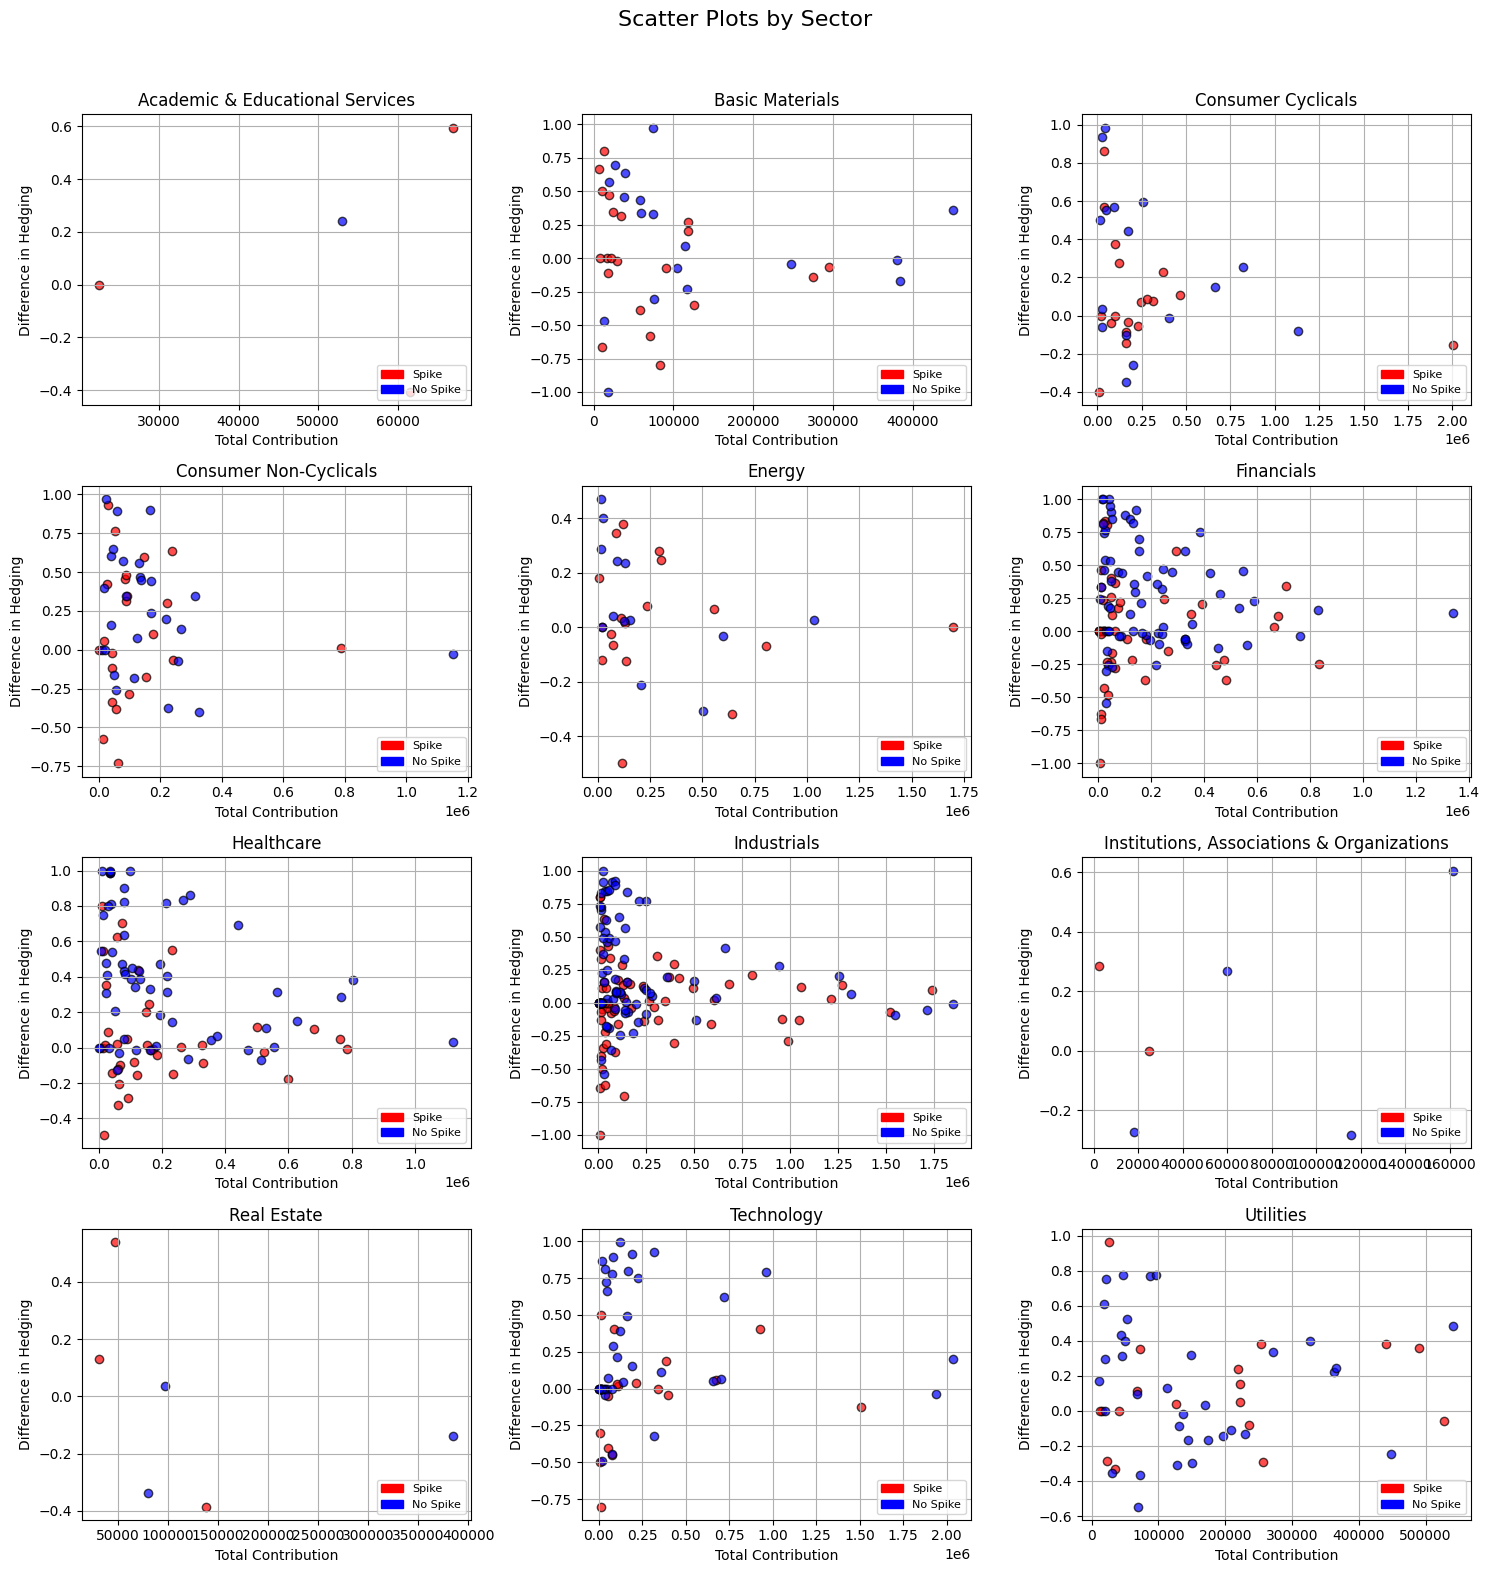

In [424]:
sectors = spike_comparison['Sector'].dropna().unique()
sectors.sort()

# Plot layout
plots_per_row = 3
n_plots = len(sectors)
n_rows = math.ceil(n_plots / plots_per_row)

fig, axs = plt.subplots(n_rows, plots_per_row, figsize=(plots_per_row * 5, n_rows * 4), squeeze=False)

spike_colors = {"Spike": "red", "No Spike": "blue"}
legend_handles = [
    mpatches.Patch(color=spike_colors["Spike"], label="Spike"),
    mpatches.Patch(color=spike_colors["No Spike"], label="No Spike")
]

for i, sector in enumerate(sectors):
    row = i // plots_per_row
    col = i % plots_per_row
    ax = axs[row][col]
    
    spike_subset = spike_comparison[spike_comparison['Sector'] == sector]
    nspike_subset = nspike_comparison[nspike_comparison['Sector'] == sector]
    ax.scatter(
        spike_subset['total_contrib'],
        spike_subset['hedge_diff'],
        alpha=0.7,
        color = spike_colors["Spike"],
        edgecolor='k'
    )
    ax.scatter(
        nspike_subset['total_contrib'],
        nspike_subset['hedge_diff'],
        alpha=0.7,
        color = spike_colors["No Spike"],
        edgecolor='k'
    )
    ax.set_title(sector)
    ax.set_xlabel('Total Contribution')
    ax.set_ylabel('Difference in Hedging')
    ax.legend(handles=legend_handles, loc="lower right", fontsize=8)
    ax.grid(True)

# Hide any unused subplots
for j in range(n_plots, n_rows * plots_per_row):
    row, col = divmod(j, plots_per_row)
    axs[row][col].set_visible(False)

plt.suptitle('Scatter Plots by Sector', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])  # reserve space for title
plt.show()

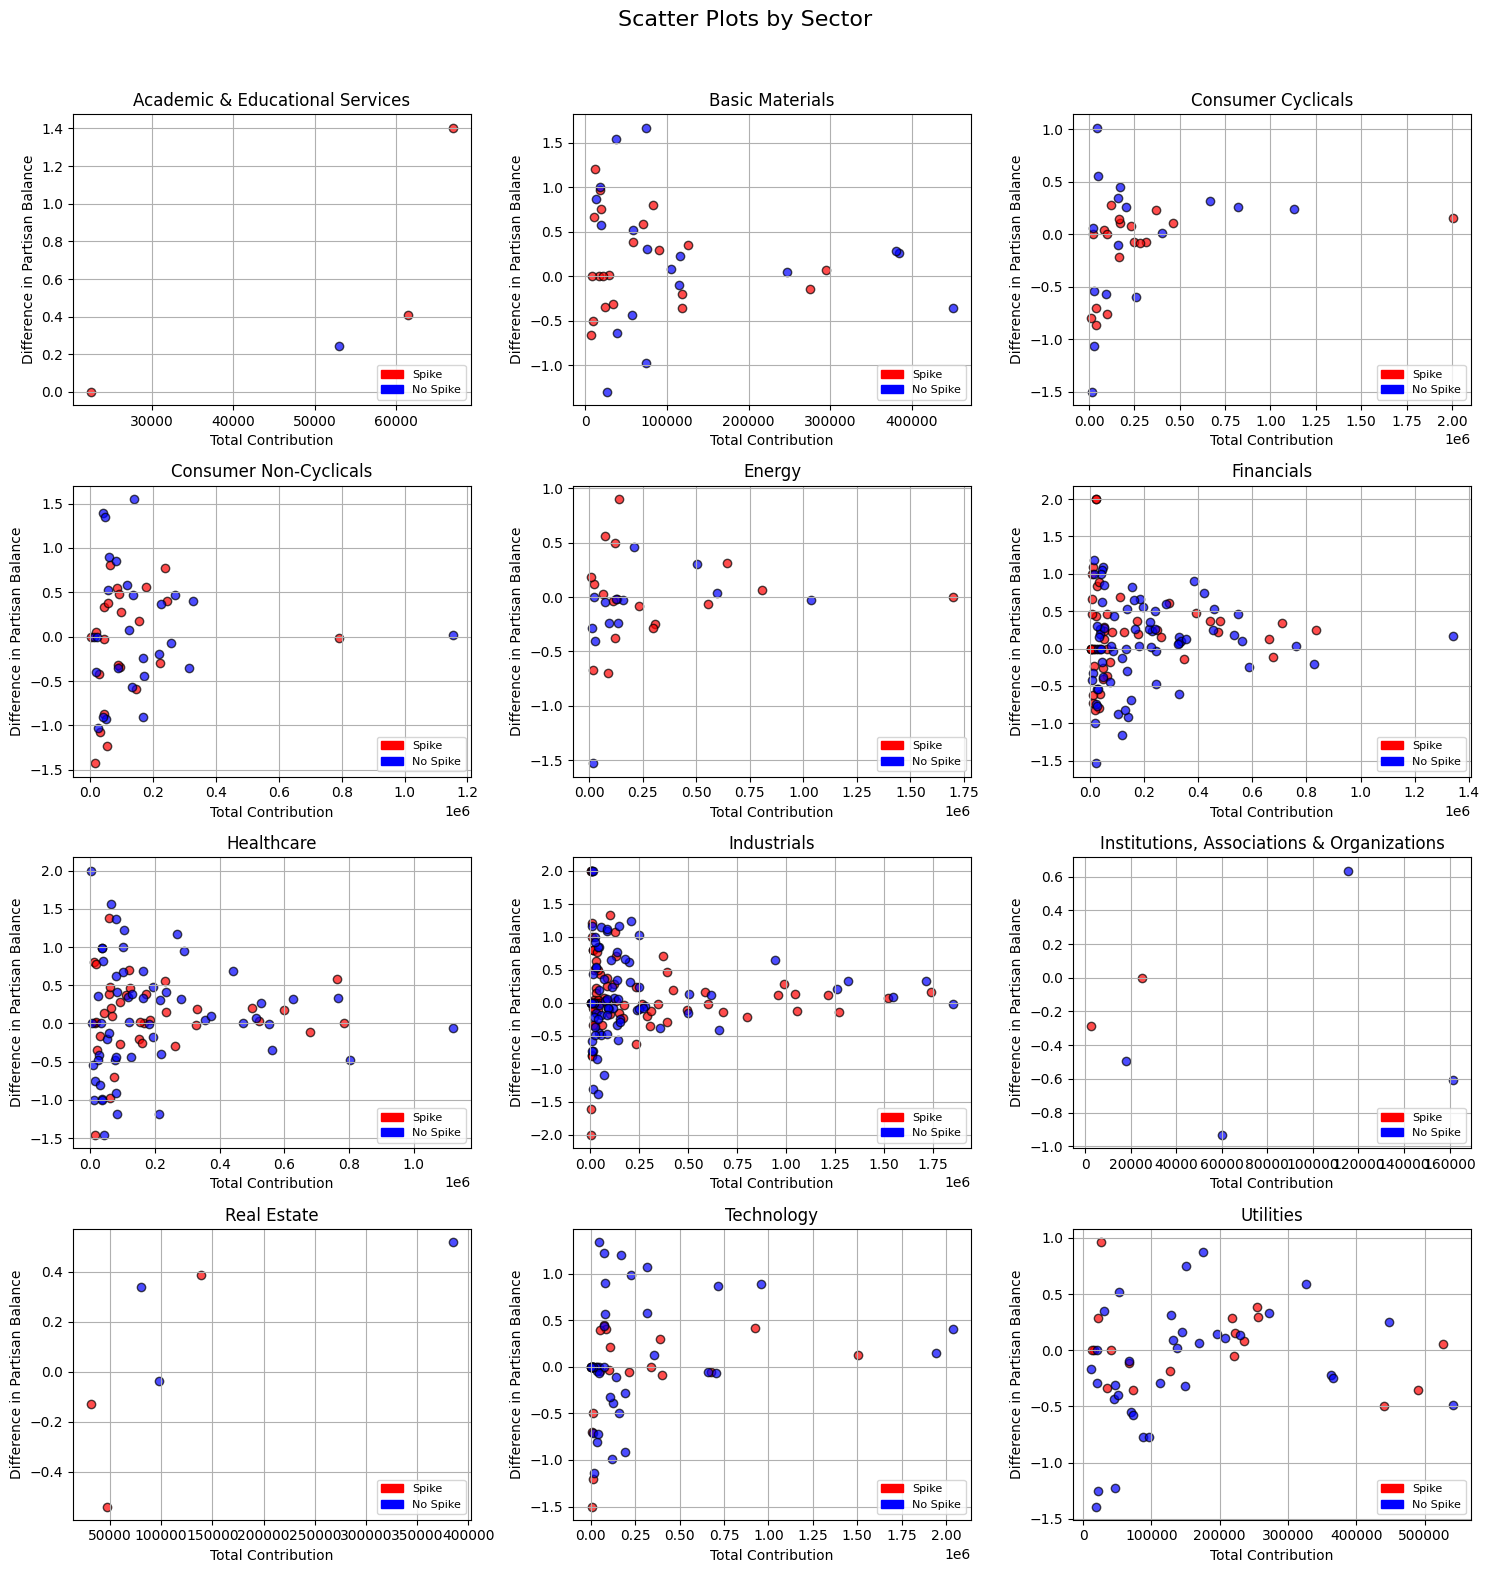

In [426]:
sectors = spike_comparison['Sector'].dropna().unique()
sectors.sort()

# Plot layout
plots_per_row = 3
n_plots = len(sectors)
n_rows = math.ceil(n_plots / plots_per_row)

fig, axs = plt.subplots(n_rows, plots_per_row, figsize=(plots_per_row * 5, n_rows * 4), squeeze=False)

spike_colors = {"Spike": "red", "No Spike": "blue"}
legend_handles = [
    mpatches.Patch(color=spike_colors["Spike"], label="Spike"),
    mpatches.Patch(color=spike_colors["No Spike"], label="No Spike")
]

for i, sector in enumerate(sectors):
    row = i // plots_per_row
    col = i % plots_per_row
    ax = axs[row][col]
    
    spike_subset = spike_comparison[spike_comparison['Sector'] == sector]
    nspike_subset = nspike_comparison[nspike_comparison['Sector'] == sector]
    ax.scatter(
        spike_subset['total_contrib'],
        spike_subset['balance_diff'],
        alpha=0.7,
        color = spike_colors["Spike"],
        edgecolor='k'
    )
    ax.scatter(
        nspike_subset['total_contrib'],
        nspike_subset['balance_diff'],
        alpha=0.7,
        color = spike_colors["No Spike"],
        edgecolor='k'
    )
    ax.set_title(sector)
    ax.set_xlabel('Total Contribution')
    ax.set_ylabel('Difference in Partisan Balance')
    ax.legend(handles=legend_handles, loc="lower right", fontsize=8)
    ax.grid(True)

# Hide any unused subplots
for j in range(n_plots, n_rows * plots_per_row):
    row, col = divmod(j, plots_per_row)
    axs[row][col].set_visible(False)

plt.suptitle('Scatter Plots by Sector', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])  # reserve space for title
plt.show()